In [ ]:
# 필요 패키지 설치
!pip install kiwipiepy konlpy --quiet

from kiwipiepy import Kiwi
from konlpy.tag import Okt
from sklearn.feature_extraction.text import TfidfVectorizer
from collections import Counter
from nltk import ngrams
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.0/88.0 MB 8.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 17.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.4/19.4 MB 58.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 495.9/495.9 kB 28.8 MB/s eta 0:00:00


In [ ]:
# 한글 폰트 — 세션 시작할 때마다 실행
import subprocess
subprocess.run(['apt-get', 'install', '-y', '-q', 'fonts-nanum'], capture_output=True)

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 캐시 초기화 후 폰트 등록
fm.fontManager.__init__()
font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
fm.fontManager.addfont(font_path)

plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

print("✅ 폰트 설정 완료:", plt.rcParams['font.family'])

✅ 폰트 설정 완료: ['NanumGothic']


In [ ]:
from google.colab import files

uploaded = files.upload()
# → 실행하면 "파일 선택" 버튼 뜸
# → 문재인_취임사.txt, 윤석열_취임사.txt 두 개 선택

Saving 문재인 취임사.txt to 문재인 취임사.txt
Saving 윤석열 취임사.txt to 윤석열 취임사.txt


In [ ]:
# 업로드 확인
import os
print(os.listdir())  # 두 파일이 보이면 성공

['.config', '윤석열 취임사.txt', '문재인 취임사.txt', 'sample_data']


In [ ]:
# 텍스트 로드 및 글자수
with open("문재인 취임사.txt", encoding="utf-8") as f:
    moon = f.read()
with open("윤석열 취임사.txt", encoding="utf-8") as f:
    yoon = f.read()

print("문재인:", len(moon), "자")
print("윤석열:", len(yoon), "자")

문재인: 3162 자
윤석열: 3518 자


In [ ]:
# ══════════════════════════════════════════════════════
# STEP 1. 패키지 설치 & 임포트
# ══════════════════════════════════════════════════════
!pip install kiwipiepy konlpy --quiet # 형태소 분석기//맨 위에 설치하였으나 다시 설치함 (step1은 생략해도 무방함)
!apt-get install -y fonts-nanum --quiet  # 한글 폰트

from kiwipiepy import Kiwi
from konlpy.tag import Okt
import re

# ══════════════════════════════════════════════════════
# STEP 2. 기본 전처리 (형태소 분석 전)
# ══════════════════════════════════════════════════════

def clean_text(text):
    text = re.sub(r"\[.*?\]", "", text)      # [출처] 등 괄호 메타정보 제거
    text = re.sub(r"[^\w\s]", " ", text)     # 특수문자 제거 (·, ', 마침표 등)
    text = re.sub(r"\s+", " ", text)         # 다중 공백 → 단일 공백
    return text.strip()

moon_clean = clean_text(moon)
yoon_clean = clean_text(yoon)

print("전처리 전:", moon[:50])
print("전처리 후:", moon_clean[:50])

Reading package lists...
Building dependency tree...
Reading state information...
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.
전처리 전: 존경하고 사랑하는 국민 여러분. 감사합니다. 국민 여러분의 위대한 선택에 머리 숙여 깊이 
전처리 후: 존경하고 사랑하는 국민 여러분 감사합니다 국민 여러분의 위대한 선택에 머리 숙여 깊이 감사


In [ ]:
# 어절 수 구하기
moon_eojeol = len(moon.split())
yoon_eojeol  = len(yoon.split())

print("문재인 취임사:", moon_eojeol, "어절")
print("윤석열 취임사:", yoon_eojeol, "어절")
print("전체 코퍼스:", moon_eojeol + yoon_eojeol, "어절")

문재인 취임사: 662 어절
윤석열 취임사: 819 어절
전체 코퍼스: 1481 어절


In [ ]:
# ══════════════════════════════════════════════════════
# STEP 3. 형태소 분석기 비교
# — 어떤 분석기를 쓸지 결정하기 위한 탐색 단계
# ══════════════════════════════════════════════════════

kiwi = Kiwi()
okt  = Okt()

# 테스트 문장으로 먼저 비교
test = "자유민주주의와 시장경제 체제를 기반으로 국민이 진정한 주인인 나라"

print("=== Kiwi ===")
for token in kiwi.tokenize(test):
    print(f"  {token.form:12s}  {token.tag}")

print("\n=== OKT ===")
for form, pos in okt.pos(test):
    print(f"  {form:12s}  {pos}")

# Kiwi를 써야 하는 경우
#형태소 단위 통계 분석 (TTR, MTLD 등)
#품사 기반 연구
#문법 구조 분석
#학술 논문

#Okt를 써도 되는 경우
#대규모 데이터 빠른 전처리
#감성 분석
#SNS 데이터
#단순 토큰화

=== Kiwi ===
  자유            NNG
  민주주의          NNG
  와             JC
  시장            NNG
  경제            NNG
  체제            NNG
  를             JKO
  기반            NNG
  으로            JKB
  국민            NNG
  이             JKS
  진정            XR
  하             XSA
  ᆫ             ETM
  주인            NNG
  이             VCP
  ᆫ             ETM
  나라            NNG

=== OKT ===
  자유            Noun
  민주주의          Noun
  와             Josa
  시장경제          Noun
  체제            Noun
  를             Josa
  기반            Noun
  으로            Josa
  국민            Noun
  이             Josa
  진정한           Adjective
  주인            Noun
  인             Josa
  나라            Noun


In [ ]:
# ══════════════════════════════════════════════════════
# STEP 4. 분석기 선택 근거 확인
# ══════════════════════════════════════════════════════

# Kiwi 품사 태그 체계
# NNG  일반명사     VV   동사
# NNP  고유명사     VA   형용사
# NNB  의존명사     MAG  일반부사
# JX   보조사       EC   연결어미  ← 이런 기능어는 제거

keep_pos = {"NNG", "NNP", "VV", "VA", "MAG"}  # 내용어만 유지

def tokenize_kiwi(text):
    tokens = kiwi.tokenize(text)
    return [t.form for t in tokens if t.tag in keep_pos]

moon_tokens = tokenize_kiwi(moon_clean)
yoon_tokens  = tokenize_kiwi(yoon_clean)

print("문재인 토큰 수:", len(moon_tokens))
print("윤석열 토큰 수:", len(yoon_tokens))
print("\n문재인 샘플:", moon_tokens[:20])
print("윤석열 샘플:", yoon_tokens[:20])

문재인 토큰 수: 573
윤석열 토큰 수: 667

문재인 샘플: ['존경', '사랑', '국민', '감사', '국민', '위대하', '선택', '머리', '숙이', '깊이', '감사', '드리', '오늘', '대한민국', '대통령', '대한민국', '향하', '첫걸음', '지금', '어깨']
윤석열 샘플: ['존경', '사랑', '국민', '재외', '동포', '자유', '사랑', '세계', '시민', '나라', '자유', '민주주의', '시장', '경제', '체제', '기반', '국민', '주인', '나라', '재건']


In [ ]:
# ══════════════════════════════════════════════════════
# STEP 5. 불용어 처리
# — keep_pos 필터 후에도 남는 불필요 어휘 제거
# ══════════════════════════════════════════════════════

stopwords = {
    "있다", "하다", "되다", "이다", "없다",
    "같다", "않다", "위하다", "통하다",
    "그", "이", "저", "것", "수", "등"
}

def tokenize_clean(text):
    tokens = kiwi.tokenize(text)
    return [
        t.form for t in tokens
        if t.tag in keep_pos
        and t.form not in stopwords
        and len(t.form) > 1   # 1글자 단어 제거
    ]

moon_final = tokenize_clean(moon_clean)
yoon_final  = tokenize_clean(yoon_clean)

print("불용어 처리 후 문재인 토큰 수:", len(moon_final))
print("불용어 처리 후 윤석열 토큰 수:", len(yoon_final))

불용어 처리 후 문재인 토큰 수: 497
불용어 처리 후 윤석열 토큰 수: 605


In [ ]:
# ══════════════════════════════════════════════════════
# STEP 6. 전처리 결과 점검
# — TF-IDF 투입 전 최종 확인
# ══════════════════════════════════════════════════════

from collections import Counter

moon_freq = Counter(moon_final)
yoon_freq  = Counter(yoon_final)

print("=== 문재인 단순 빈도 상위 10 ===")
for word, cnt in moon_freq.most_common(10):
    print(f"  {word:10s}  {cnt}")

print("\n=== 윤석열 단순 빈도 상위 10 ===")
for word, cnt in yoon_freq.most_common(10):
    print(f"  {word:10s}  {cnt}")

# ↑ 여기서 불필요한 단어가 상위에 보이면
#   stopwords에 추가하고 STEP 5부터 다시 실행

=== 문재인 단순 빈도 상위 10 ===
  대통령         34
  국민          26
  대한민국        10
  나라          10
  만들          9
  역사          7
  선거          7
  위하          6
  정치          6
  존경          5

=== 윤석열 단순 빈도 상위 10 ===
  자유          35
  국민          15
  시민          15
  세계          13
  사회          12
  평화          12
  나라          10
  국제          9
  해결          9
  민주주의        8


In [ ]:
# ══════════════════════════════════════════════════════
# STEP 7. TF-IDF 분석  【Activity B 연결】
# ══════════════════════════════════════════════════════
from sklearn.feature_extraction.text import TfidfVectorizer

moon_str = " ".join(moon_final)
yoon_str = " ".join(yoon_final)

# D=2이므로 min_df=1 (min_df=2로 하면 공통어만 남아 분석 무의미)
vectorizer   = TfidfVectorizer(min_df=1, max_df=1.0)
tfidf_matrix = vectorizer.fit_transform([moon_str, yoon_str])

features = vectorizer.get_feature_names_out()
df_tfidf = pd.DataFrame(
    tfidf_matrix.toarray(),
    index=["문재인", "윤석열"],
    columns=features
)

n_top = 15
for name in ["문재인", "윤석열"]:
    top = df_tfidf.loc[name].sort_values(ascending=False).head(n_top)
    print(f"\n=== {name} TF-IDF 상위 {n_top} ===")
    for word, score in top.items():
        print(f"  {word:12s}  {score:.4f}")


=== 문재인 TF-IDF 상위 15 ===
  대통령           0.5781
  국민            0.4420
  나라            0.1700
  대한민국          0.1700
  선거            0.1673
  만들            0.1530
  세상            0.1195
  역사            0.1190
  정치            0.1020
  위하            0.1020
  약속            0.0956
  시작            0.0956
  이번            0.0956
  권력            0.0956
  함께            0.0850

=== 윤석열 TF-IDF 상위 15 ===
  자유            0.6352
  세계            0.2359
  사회            0.2178
  국민            0.1937
  시민            0.1937
  국제            0.1633
  평화            0.1550
  민주주의          0.1452
  나라            0.1291
  가치            0.1270
  해결            0.1162
  연대            0.1089
  위기            0.1033
  국가            0.0907
  성장            0.0907


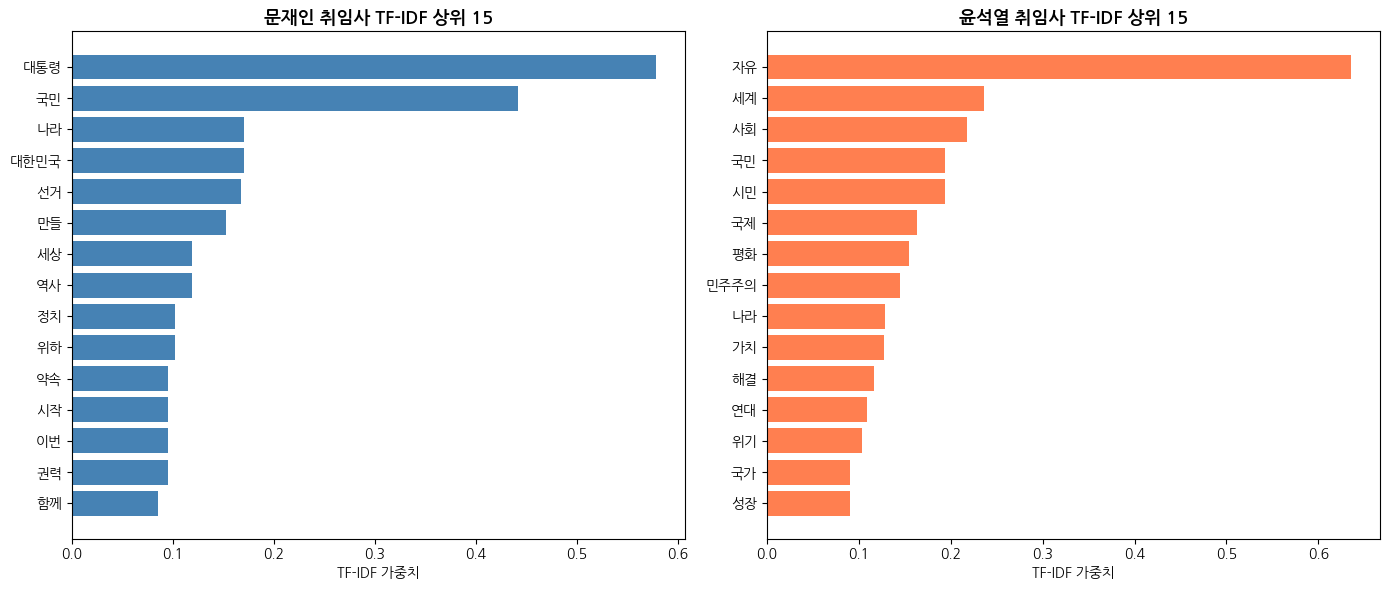

In [ ]:
# TF-IDF 시각화
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 한글 폰트 (해당 단계가 깨질 경우 맨 위의 셀 # 한글 폰트 — 세션 시작할 때마다 실행을 다시 실행할 것
plt.rcParams["font.family"] = "NanumGothic"
plt.rcParams["axes.unicode_minus"] = False

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, name, color in zip(axes,
                            ["문재인", "윤석열"],
                            ["steelblue", "coral"]):
    top = df_tfidf.loc[name].sort_values(ascending=False).head(n_top)
    ax.barh(top.index[::-1], top.values[::-1], color=color)
    ax.set_title(f"{name} 취임사 TF-IDF 상위 {n_top}",
                 fontsize=13, fontweight="bold")
    ax.set_xlabel("TF-IDF 가중치")

plt.tight_layout()
plt.show()

In [ ]:
# ══════════════════════════════════════════════════════
# STEP 8. 콜로케이션 분석  【Activity C · D 연결】
# ══════════════════════════════════════════════════════
# MI (Mutual Information)
# 초점: 결합 강도 (association strength)
# 강점: 희귀하지만 강하게 결합된 연어 탐지에 유리
# 약점: 저빈도 노이즈에 매우 취약

# MI³ (MI-cubed)
# 초점: 결합 강도 + 빈도 보정
# 강점: MI의 저빈도 문제를 완화하여 보다 안정적인 결과 제공
# 약점: 여전히 MI 계열로, 극단적 결합값 편향이 일부 존재

# t-score
# 초점: 빈도 기반 안정성 (frequency reliability)
# 강점: 고빈도·일반적 연어를 안정적으로 포착
# 약점: 희귀하지만 강한 결합 관계는 잘 포착하지 못함

# G² (Log-Likelihood, LL)
# 초점: 통계적 유의성 (significance)
# 강점: 코퍼스 규모 차이에 강건하며 균형적인 판단 가능
# 약점: 값의 해석이 직관적이지 않음

import math

def get_collocates(tokens, node, window=3, direction="both"):
    """
    direction: 'left' / 'right' / 'both'
    Activity D 방향 설정
    """
    cooc = Counter()
    for i, tok in enumerate(tokens):
        if tok == node:
            if direction in ("left", "both"):
                for w in tokens[max(0, i - window):i]:
                    if w != node:
                        cooc[w] += 1
            if direction in ("right", "both"):
                for w in tokens[i + 1:i + window + 1]:
                    if w != node:
                        cooc[w] += 1
    return cooc


def calc_collocation_stats(O11, node_freq, col_freq, total):
    """MI / MI³ / t-score / G²(LL) 동시 산출"""
    E11 = (node_freq * col_freq) / total
    if E11 == 0 or O11 == 0:
        return dict(MI=0, MI3=0, t_score=0, LL=0)

    mi   = math.log2(O11 / E11)
    mi3  = math.log2((O11 ** 3) / E11)
    t    = (O11 - E11) / math.sqrt(O11)

    O12  = node_freq - O11
    O21  = col_freq  - O11
    E12  = node_freq  * (total - col_freq)  / total
    E21  = col_freq   * (total - node_freq) / total
    E22  = (total - node_freq) * (total - col_freq) / total
    O22  = total - O11 - O12 - O21

    def _ll(o, e): return o * math.log(o / e) if o > 0 and e > 0 else 0
    g2 = 2 * (_ll(O11,E11) + _ll(O12,E12) + _ll(O21,E21) + _ll(O22,E22))

    return dict(MI=round(mi,3), MI3=round(mi3,3),
                t_score=round(t,3), LL=round(g2,3))

In [ ]:
# ── Activity C: 동일 노드, 4지표 비교 ────────────────────────────────

# ★ 노드 단어와 window 크기 여기서 바꾸세요 ★
NODE   = "대통령"
WINDOW = 3

all_tokens = moon_final + yoon_final
total      = len(all_tokens)
word_freq  = Counter(all_tokens)

if NODE not in word_freq:
    print(f"'{NODE}' 없음. 고빈도 단어:", [w for w, _ in word_freq.most_common(10)])
else:
    cooc      = get_collocates(all_tokens, NODE, window=WINDOW, direction="both")
    node_freq = word_freq[NODE]

    rows = []
    for word, freq in cooc.most_common(50):
        stats = calc_collocation_stats(freq, node_freq, word_freq[word], total)
        stats.update({"단어": word, "공기빈도": freq})
        rows.append(stats)

    df_cooc = pd.DataFrame(rows)[["단어", "공기빈도", "MI", "MI3", "t_score", "LL"]]

    print(f"노드: '{NODE}' | window={WINDOW} | 코퍼스={total}토큰\n")
    for metric in ["MI", "MI3", "t_score", "LL"]:
        print(f"── {metric} 상위 5 ──")
        print(df_cooc.sort_values(metric, ascending=False)
                     .head(5)[["단어", "공기빈도", metric]]
                     .to_string(index=False))
        print()

노드: '국민' | window=3 | 코퍼스=1102토큰

── MI 상위 5 ──
단어  공기빈도    MI
감히     3 6.333
섬기     3 6.333
힘들     2 5.748
앞길     2 5.748
항상     2 5.748

── MI3 상위 5 ──
 단어  공기빈도    MI3
대통령    19 12.244
 존경    12 11.918
 사랑     6  9.918
 섬기     3  9.503
 감히     3  9.503

── t_score 상위 5 ──
 단어  공기빈도  t_score
대통령    19    4.035
 존경    12    3.335
 사랑     6    2.358
 감사     6    2.313
 역사     6    2.298

── LL 상위 5 ──
 단어  공기빈도     LL
대통령    19 83.457
 존경    12 82.776
 사랑     6 40.387
 감사     6 29.125
 마음     4 29.028



In [ ]:
# ── Activity D: 방향(direction) 설정 비교 ────────────────────────────

if NODE in word_freq:
    print(f"노드: '{NODE}' — 방향별 상위 5\n")
    configs = [
        ("left",  f"L{WINDOW}  수식어·관형어"),
        ("right", f"R{WINDOW}  서술어 패턴"),
        ("both",  f"L{WINDOW}R{WINDOW} 담화 주제"),
    ]
    for direction, label in configs:
        top5 = get_collocates(all_tokens, NODE,
                               window=WINDOW,
                               direction=direction).most_common(5)
        words = "  /  ".join(f"{w}({c})" for w, c in top5)
        print(f"  [{label}]  {words}")

노드: '국민' — 방향별 상위 5

  [L3  수식어·관형어]  존경(12)  /  대통령(9)  /  사랑(6)  /  감사(4)  /  만들(3)
  [R3  서술어 패턴]  대통령(10)  /  세계(4)  /  지금(3)  /  대한민국(3)  /  역사(3)
  [L3R3 담화 주제]  대통령(19)  /  존경(12)  /  사랑(6)  /  감사(6)  /  역사(6)


In [ ]:
# ══════════════════════════════════════════════════════
# STEP 9. N-gram 분석  【Activity E · F 연결】
# ══════════════════════════════════════════════════════
from nltk import ngrams

# ── 어절 N-gram (원문 공백 분리) ──────────────────────
def eojeol_tokens(text):
    return [t for t in text.split() if len(t) > 1]

moon_eojeol = eojeol_tokens(moon)
yoon_eojeol = eojeol_tokens(yoon)

# ── 형태소 N-gram (Kiwi 전체 품사) ───────────────────
moon_morph = [t.form for t in kiwi.tokenize(moon_clean)]
yoon_morph = [t.form for t in kiwi.tokenize(yoon_clean)]

# ── 품사 태그 N-gram ──────────────────────────────────
moon_pos_seq = [t.tag for t in kiwi.tokenize(moon_clean)]
yoon_pos_seq = [t.tag for t in kiwi.tokenize(yoon_clean)]

# N값 설정
N = 2   # ← bigram=2 / trigram=3 / 4-gram=4

for label, tokens in [
    ("어절 bigram (문재인)",    moon_eojeol),
    ("어절 bigram (윤석열)",    yoon_eojeol),
    ("형태소 bigram (문재인)",  moon_morph),
    ("형태소 bigram (윤석열)",  yoon_morph),
    ("품사태그 bigram (문재인)", moon_pos_seq),
    ("품사태그 bigram (윤석열)", yoon_pos_seq),
]:
    top5 = Counter(ngrams(tokens, N)).most_common(5)
    print(f"\n[{label}]")
    for gram, freq in top5:
        print(f"  {' + '.join(gram):30s}  {freq}회")


[어절 bigram (문재인)]
  대통령이 + 되겠습니다.                   11회
  국민 + 여러분.                       4회
  존경하는 + 국민                       3회
  소통하는 + 대통령이                     3회
  세상을 + 만들겠습니다.                   3회

[어절 bigram (윤석열)]
  국민 + 여러분,                       6회
  세계 + 시민                         5회
  존경하는 + 국민                       5회
  시민 + 여러분,                       4회
  자유 + 시민이                        4회

[형태소 bigram (문재인)]
  겠 + 습니다                         62회
  하 + 겠                           21회
  하 + ᆫ                           19회
  대통령 + 이                         17회
  이 + 되                           16회

[형태소 bigram (윤석열)]
  하 + 는                           23회
  하 + ᆫ                           22회
  하 + ᆸ니다                         16회
  어야 + 하                          14회
  이 + ᆸ니다                         13회

[품사태그 bigram (문재인)]
  ETM + NNG                       75회
  EP + EF                         71회
  NNG + XSV                       66회
  EF + NNG                        61

In [ ]:
# ══════════════════════════════════════════════════════
# STEP 10. 키워드 분석  【Activity G · H 연결】
# ══════════════════════════════════════════════════════

def keyword_analysis(target_tokens, ref_tokens):
    """LL(G²) + Log Ratio + %DIFF 동시 산출"""
    freq_t = Counter(target_tokens)
    freq_r = Counter(ref_tokens)
    T = len(target_tokens)
    R = len(ref_tokens)

    rows = []
    for word in set(freq_t) | set(freq_r):
        O11 = freq_t.get(word, 0)
        O12 = freq_r.get(word, 0)
        N   = T + R
        E11 = T * (O11 + O12) / N
        E12 = R * (O11 + O12) / N

        def _ll(o, e): return o * math.log(o / e) if o > 0 and e > 0 else 0
        g2   = 2 * (_ll(O11, E11) + _ll(O12, E12))
        sign = 1 if (O11 / T) >= (O12 / R) else -1
        g2  *= sign

        # Log Ratio (효과 크기) — 0.5 smoothing으로 0 빈도 보정
        norm_t   = (O11 + 0.5) / T
        norm_r   = (O12 + 0.5) / R
        log_r    = math.log2(norm_t / norm_r)
        pct_diff = (norm_t - norm_r) / norm_r * 100

        rows.append({"단어": word, "빈도_T": O11, "빈도_R": O12,
                     "LL(G²)": round(g2, 2),
                     "LogRatio": round(log_r, 2),
                     "%DIFF": round(pct_diff, 1)})

    return (pd.DataFrame(rows)
              .sort_values("LL(G²)", ascending=False, key=abs)
              .reset_index(drop=True))


# 문재인 = Target / 윤석열 = Reference
df_kw = keyword_analysis(moon_final, yoon_final)

print("=== Positive Keywords — 문재인 특징어 (LL > 0) ===")
print(df_kw[df_kw["LL(G²)"] > 0].head(10).to_string(index=False))

print("\n=== Negative Keywords — 윤석열 특징어 (LL < 0) ===")
print(df_kw[df_kw["LL(G²)"] < 0].head(10).to_string(index=False))

=== Positive Keywords — 문재인 특징어 (LL > 0) ===
  단어  빈도_T  빈도_R  LL(G²)  LogRatio  %DIFF
 대통령    34     4   33.37      3.22  833.3
  선거     7     0   11.15      4.19 1726.0
  세상     5     0    7.96      3.74 1239.0
대한민국    10     2    7.51      2.35  411.3
  시작     4     0    6.37      3.45  995.6
  약속     4     0    6.37      3.45  995.6
  이번     4     0    6.37      3.45  995.6
  권력     4     0    6.37      3.45  995.6
  국민    26    15    5.55      1.06  108.1
  잘못     3     0    4.78      3.09  752.1

=== Negative Keywords — 윤석열 특징어 (LL < 0) ===
  단어  빈도_T  빈도_R  LL(G²)  LogRatio  %DIFF
  자유     0    35  -41.98     -5.87  -98.3
  세계     0    13  -15.59     -4.47  -95.5
  사회     0    12  -14.39     -4.36  -95.1
  국제     0     9  -10.79     -3.96  -93.6
민주주의     0     8   -9.59     -3.80  -92.8
  시민     2    15   -8.86     -2.35  -80.4
  가치     0     7   -8.40     -3.62  -91.9
  연대     0     6   -7.20     -3.42  -90.6
  과학     0     5   -6.00     -3.18  -88.9
  국가     0     5   -6.00   

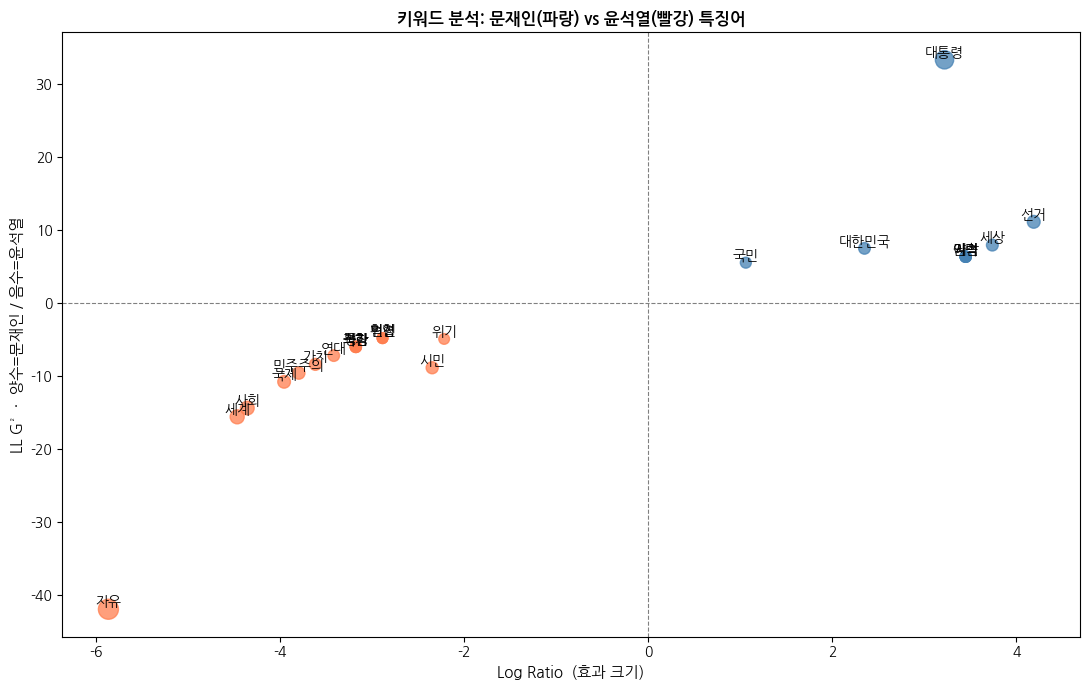

In [ ]:
# 버블 차트 (LL × Log Ratio)
df_plot = df_kw.copy()
df_plot["abs_LL"] = df_plot["LL(G²)"].abs()
df_top  = df_plot.nlargest(25, "abs_LL")

fig, ax = plt.subplots(figsize=(11, 7))
colors  = df_top["LL(G²)"].apply(lambda x: "steelblue" if x > 0 else "coral")

ax.scatter(df_top["LogRatio"], df_top["LL(G²)"],
           s=df_top["abs_LL"] * 4 + 40,
           c=colors, alpha=0.75)

for _, row in df_top.iterrows():
    ax.annotate(row["단어"],
                (row["LogRatio"], row["LL(G²)"]),
                fontsize=10, ha="center", va="bottom")

ax.axhline(0, color="gray", lw=0.8, ls="--")
ax.axvline(0, color="gray", lw=0.8, ls="--")
ax.set_xlabel("Log Ratio  (효과 크기)", fontsize=11)
ax.set_ylabel("LL G²  ·  양수=문재인 / 음수=윤석열", fontsize=11)
ax.set_title("키워드 분석: 문재인(파랑) vs 윤석열(빨강) 특징어",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()